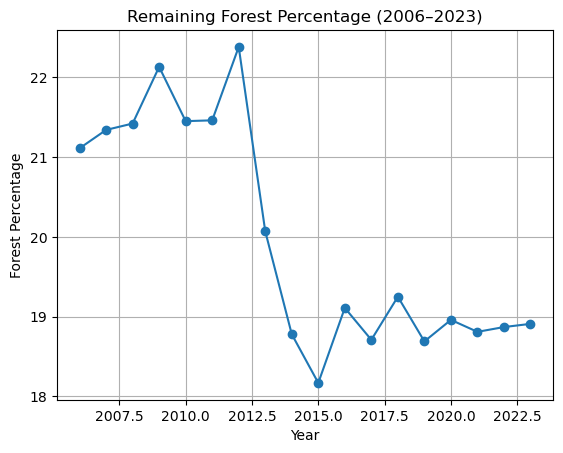

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Forest percentage data from 2006 to 2023
years = list(range(2006, 2024))
forest_percentages = [
    21.11, 21.34, 21.42, 22.13, 21.45, 21.46, 22.38, 20.07, 18.78,
    18.17, 19.11, 18.71, 19.25, 18.69, 18.96, 18.81, 18.87, 18.91
]

# Create a pandas Series
forest_series = pd.Series(forest_percentages, index=pd.Index(years, name="Year"))
forest_series.plot(title="Remaining Forest Percentage (2006–2023)", marker='o')
plt.ylabel("Forest Percentage")
plt.grid(True)
plt.show()


In [2]:
# Fit ARIMA model (p=1, d=1, q=1) as a starting point
model = ARIMA(forest_series, order=(1, 1, 1))
model_fit = model.fit()

# Print summary of the model
print(model_fit.summary())


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA paramete

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   18
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -20.302
Date:                Sat, 12 Apr 2025   AIC                             46.604
Time:                        13:02:55   BIC                             49.104
Sample:                             0   HQIC                            46.853
                                 - 18                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9163      1.733      0.529      0.597      -2.481       4.314
ma.L1         -0.9978     30.704     -0.032      0.974     -61.177      59.181
sigma2         0.6190     18.023      0.034      0.9

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


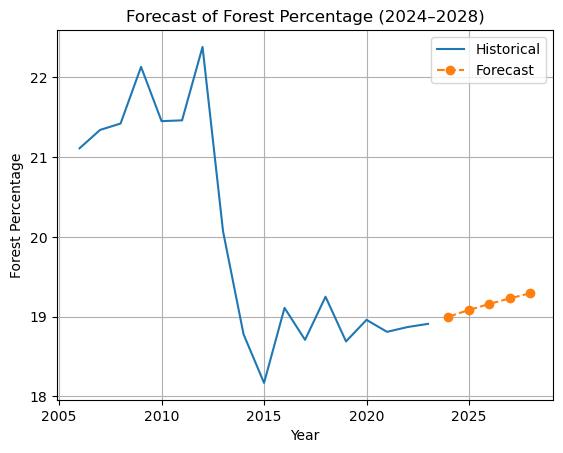

Forecast for 2024: 19.00%
Forecast for 2025: 19.08%
Forecast for 2026: 19.16%
Forecast for 2027: 19.23%
Forecast for 2028: 19.29%


In [3]:
forecast = model_fit.forecast(steps=5)
forecast_years = list(range(2024, 2029))

# Plot actual and forecasted data
plt.plot(forest_series, label="Historical")
plt.plot(forecast_years, forecast, label="Forecast", marker='o', linestyle='--')
plt.title("Forecast of Forest Percentage (2024–2028)")
plt.ylabel("Forest Percentage")
plt.xlabel("Year")
plt.legend()
plt.grid(True)
plt.show()

# View forecasted values
for year, value in zip(forecast_years, forecast):
    print(f"Forecast for {year}: {value:.2f}%")


In [6]:
!pip install pmdarima


In [7]:
from pmdarima import auto_arima

stepwise_model = auto_arima(forest_series, seasonal=False, trace=True)
print(stepwise_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=44.388, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=46.305, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=46.289, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=42.834, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.861 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   18
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -20.417
Date:                Sat, 12 Apr 2025   AIC                             42.834
Time:                        13:05:18   BIC                             43.667
Sample:                             0   HQIC                            42.917
                            